## Resources

In [ ]:
!pip install openpyxl

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from datetime import timedelta
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette("muted")

In [4]:
import zipfile
import os

# Define the path to the uploaded zip file
zip_file_path = '/content/archive (2).zip'

# Define the directory where files will be extracted
extract_dir = '/content/extracted_data'
os.makedirs(extract_dir, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

# Find the csv file within the extracted directory
csv_file_name = None
for root, dirs, files in os.walk(extract_dir):
    for file in files:
        if file.endswith('.csv'):
            csv_file_name = os.path.join(root, file)
            break
    if csv_file_name:
        break

if csv_file_name:
    print(f"Found CSV file: {csv_file_name}")
    # Load the CSV file
    df = pd.read_csv(csv_file_name)

    print(f"Total rows loaded: {len(df):,}")
    print(df.head())
else:
    print("No .csv file found in the extracted archive.")

Found CSV file: /content/extracted_data/online_retail_II.csv
Total rows loaded: 1,067,371
  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

           InvoiceDate  Price  Customer ID         Country  
0  2009-12-01 07:45:00   6.95      13085.0  United Kingdom  
1  2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
2  2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
3  2009-12-01 07:45:00   2.10      13085.0  United Kingdom  
4  2009-12-01 07:45:00   1.25      13085.0  United Kingdom  


In [5]:
print("--- Before cleaning ---")
print(f"Rows: {len(df):,}")
print(df.isnull().sum())

# Drop rows with no Customer ID (can't do RFM without it)
df = df.dropna(subset=['Customer ID'])

# Remove cancelled orders (Invoice starts with 'C')
df = df[~df['Invoice'].astype(str).str.startswith('C')]

# Remove rows with negative or zero quantity/price
df = df[df['Quantity'] > 0]
df = df[df['Price'] > 0]

# Create revenue column
df['Revenue'] = df['Quantity'] * df['Price']

# Make sure InvoiceDate is datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print("\n--- After cleaning ---")
print(f"Rows remaining: {len(df):,}")
print(f"Unique customers: {df['Customer ID'].nunique():,}")
print(f"Date range: {df['InvoiceDate'].min().date()} → {df['InvoiceDate'].max().date()}")

--- Before cleaning ---
Rows: 1,067,371
Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

--- After cleaning ---
Rows remaining: 805,549
Unique customers: 5,878
Date range: 2009-12-01 → 2011-12-09


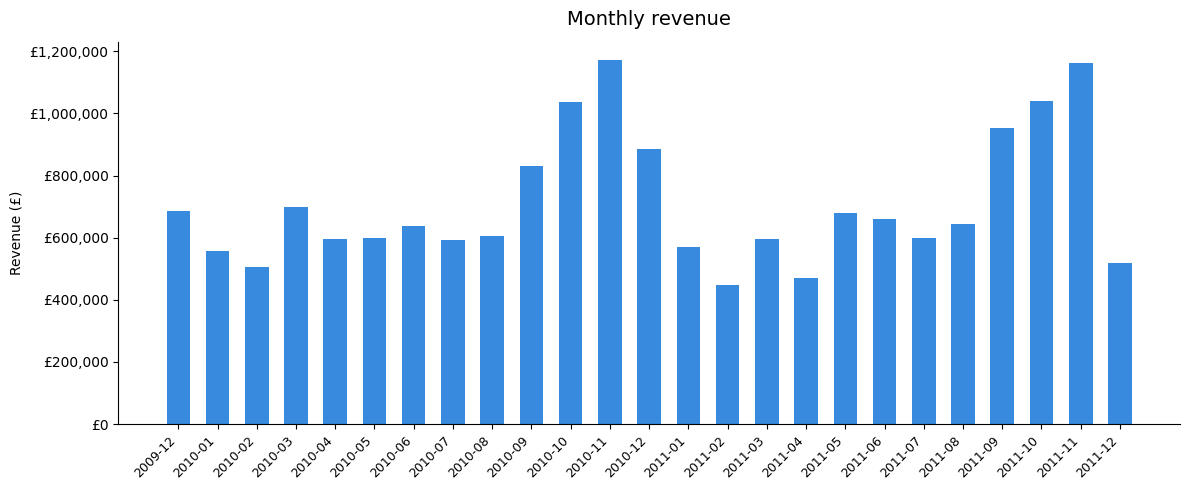

Insight: note any seasonal spikes — November/December are typically strong for retail.


In [6]:
df['Month'] = df['InvoiceDate'].dt.to_period('M')
monthly_revenue = df.groupby('Month')['Revenue'].sum().reset_index()
monthly_revenue['Month'] = monthly_revenue['Month'].astype(str)

plt.figure(figsize=(12, 5))
plt.bar(monthly_revenue['Month'], monthly_revenue['Revenue'], color='#378ADD', width=0.6)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.title('Monthly revenue', fontsize=14, fontweight='normal', pad=12)
plt.ylabel('Revenue (£)')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
plt.tight_layout()
plt.savefig('monthly_revenue.png', dpi=150, bbox_inches='tight')
plt.show()
print("Insight: note any seasonal spikes — November/December are typically strong for retail.")

In [7]:
# Use the day after last invoice as the "snapshot date"
snapshot_date = df['InvoiceDate'].max() + timedelta(days=1)
print(f"Snapshot date: {snapshot_date.date()}")

rfm = df.groupby('Customer ID').agg(
    Recency   = ('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency = ('Invoice',     'nunique'),
    Monetary  = ('Revenue',     'sum')
).reset_index()

# Score each dimension 1–4 (4 = best)
rfm['R_score'] = pd.qcut(rfm['Recency'],   q=4, labels=[4, 3, 2, 1])  # lower recency = better
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=4, labels=[1, 2, 3, 4])
rfm['M_score'] = pd.qcut(rfm['Monetary'].rank(method='first'),  q=4, labels=[1, 2, 3, 4])

rfm['RFM_score'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)
rfm['Total_score'] = rfm[['R_score','F_score','M_score']].astype(int).sum(axis=1)

# Segment labels based on total score
def label_segment(score):
    if score >= 10:
        return 'Champion'
    elif score >= 8:
        return 'Loyal'
    elif score >= 6:
        return 'At-Risk'
    elif score >= 4:
        return 'Needs Attention'
    else:
        return 'Lost'

rfm['Segment'] = rfm['Total_score'].apply(label_segment)

print(rfm[['Customer ID','Recency','Frequency','Monetary','Segment']].head(10))
print("\nSegment distribution:")
print(rfm['Segment'].value_counts())

Snapshot date: 2011-12-10
   Customer ID  Recency  Frequency  Monetary          Segment
0      12346.0      326         12  77556.46         Champion
1      12347.0        2          8   5633.32         Champion
2      12348.0       75          5   2019.40            Loyal
3      12349.0       19          4   4428.69         Champion
4      12350.0      310          1    334.40  Needs Attention
5      12351.0      375          1    300.93  Needs Attention
6      12352.0       36         10   2849.84         Champion
7      12353.0      204          2    406.76          At-Risk
8      12354.0      232          1   1079.40          At-Risk
9      12355.0      214          2    947.61          At-Risk

Segment distribution:
Segment
Champion           1738
At-Risk            1220
Loyal              1190
Needs Attention    1155
Lost                575
Name: count, dtype: int64


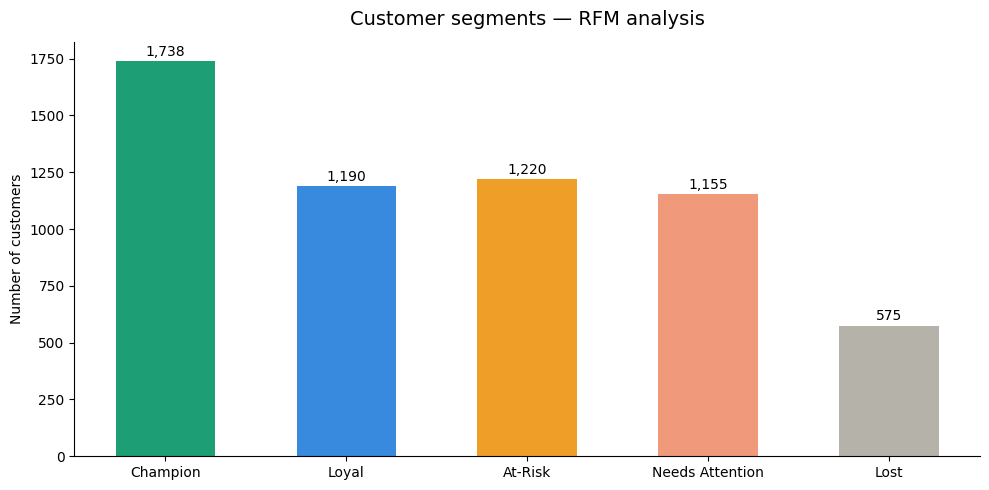

In [8]:
seg_counts = rfm['Segment'].value_counts().reindex(
    ['Champion','Loyal','At-Risk','Needs Attention','Lost'])

colors = ['#1D9E75','#378ADD','#EF9F27','#F0997B','#B4B2A9']

plt.figure(figsize=(10, 5))
bars = plt.bar(seg_counts.index, seg_counts.values, color=colors, width=0.55)
plt.title('Customer segments — RFM analysis', fontsize=14, fontweight='normal', pad=12)
plt.ylabel('Number of customers')
for bar, val in zip(bars, seg_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             f'{val:,}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig('rfm_segments.png', dpi=150, bbox_inches='tight')
plt.show()

Churn risk by segment:
                 Churned customers  Total customers  Churn rate %
Segment                                                          
Champion                       160             1738           9.2
Loyal                          462             1190          38.8
At-Risk                        772             1220          63.3
Needs Attention               1020             1155          88.3
Lost                           575              575         100.0


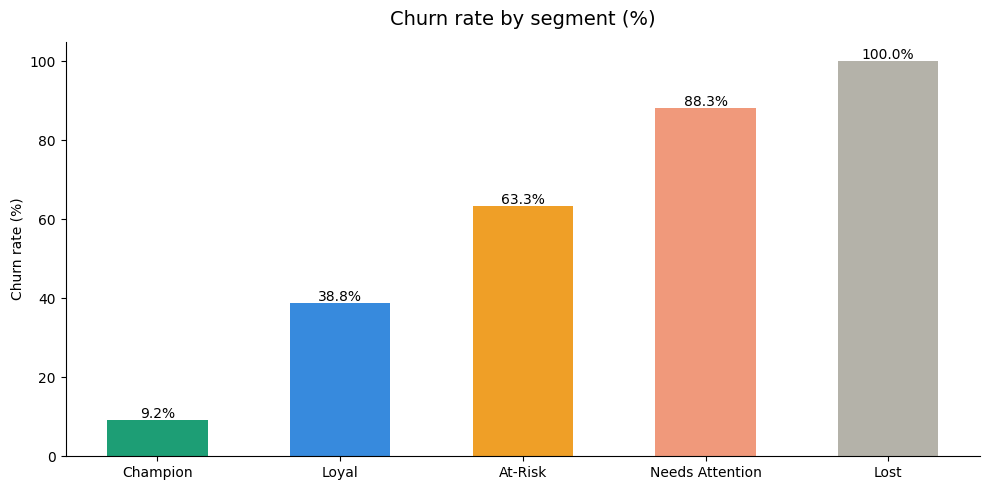

In [9]:
# Define churn = no purchase in last 90 days

rfm['Churned'] = rfm['Recency'] > 90

churn_by_segment = rfm.groupby('Segment')['Churned'].agg(['sum','count'])
churn_by_segment['churn_rate_%'] = (churn_by_segment['sum'] / churn_by_segment['count'] * 100).round(1)
churn_by_segment = churn_by_segment.reindex(['Champion','Loyal','At-Risk','Needs Attention','Lost'])
churn_by_segment.columns = ['Churned customers','Total customers','Churn rate %']

print("Churn risk by segment:")
print(churn_by_segment)

plt.figure(figsize=(10, 5))
plt.bar(churn_by_segment.index, churn_by_segment['Churn rate %'], color=colors, width=0.55)
plt.title('Churn rate by segment (%)', fontsize=14, fontweight='normal', pad=12)
plt.ylabel('Churn rate (%)')
for i, (idx, row) in enumerate(churn_by_segment.iterrows()):
    plt.text(i, row['Churn rate %'] + 0.5, f"{row['Churn rate %']}%",
             ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('churn_by_segment.png', dpi=150, bbox_inches='tight')
plt.show()

CLV estimate by segment:
           Segment  Avg_order_value  Avg_frequency  Estimated_CLV  \
0          At-Risk           399.26           2.50        1999.57   
1         Champion           513.71          15.25       15672.03   
2             Lost           176.93           1.00         353.87   
3            Loyal           411.81           4.39        3616.34   
4  Needs Attention           286.45           1.39         795.11   

   Customer_count  
0            1220  
1            1738  
2             575  
3            1190  
4            1155  


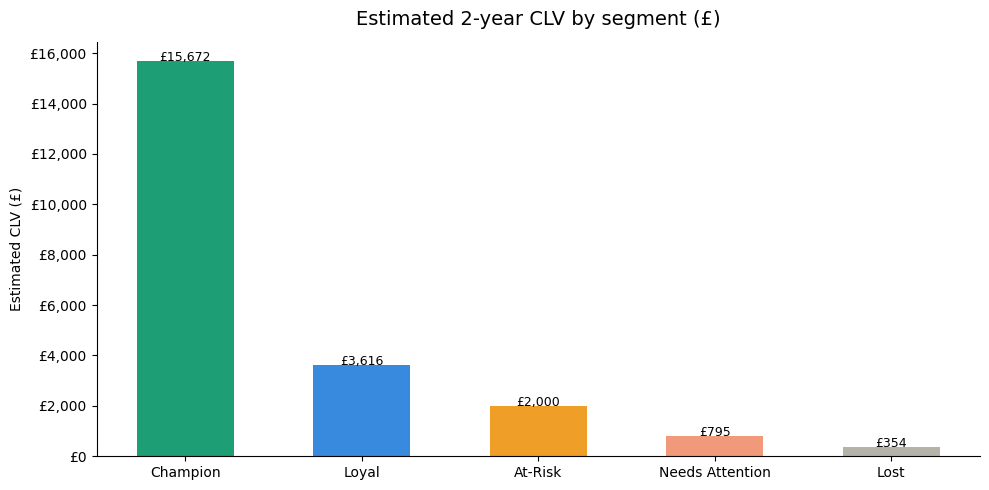

In [10]:
# Simple CLV = avg order value × avg frequency × assumed 2-year horizon
clv = rfm.groupby('Segment').agg(
    Avg_order_value = ('Monetary', lambda x: (x / rfm.loc[x.index, 'Frequency']).mean()),
    Avg_frequency   = ('Frequency', 'mean'),
    Customer_count  = ('Customer ID', 'count')
).reset_index()

clv['Estimated_CLV'] = (clv['Avg_order_value'] * clv['Avg_frequency'] * 2).round(2)
clv = clv.reindex([0,1,2,3,4])  # reorder naturally

print("CLV estimate by segment:")
print(clv[['Segment','Avg_order_value','Avg_frequency','Estimated_CLV','Customer_count']].round(2))

plt.figure(figsize=(10, 5))
clv_sorted = clv.sort_values('Estimated_CLV', ascending=False)
plt.bar(clv_sorted['Segment'], clv_sorted['Estimated_CLV'], color=colors, width=0.55)
plt.title('Estimated 2-year CLV by segment (£)', fontsize=14, fontweight='normal', pad=12)
plt.ylabel('Estimated CLV (£)')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
for i, (_, row) in enumerate(clv_sorted.iterrows()):
    plt.text(i, row['Estimated_CLV'] + 10, f"£{row['Estimated_CLV']:,.0f}",
             ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('clv_by_segment.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
recommendations = {
    'Champion':         'Referral programme + early access to new products. Highest ROI segment — reward loyalty.',
    'Loyal':            'Upsell higher-value products. Cross-sell complementary categories. Low effort, high return.',
    'At-Risk':          'Win-back email campaign — personalised offer within 2 weeks. Time-sensitive.',
    'Needs Attention':  'Re-engagement sequence. Survey to understand drop-off reason. Consider discount incentive.',
    'Lost':             'Final win-back attempt with strong offer. If no response, sunset or re-permission flow.'
}

print("=" * 65)
print("MARKETING RECOMMENDATIONS BY SEGMENT")
print("=" * 65)
for seg, rec in recommendations.items():
    count = rfm[rfm['Segment'] == seg].shape[0]
    pct   = round(count / len(rfm) * 100, 1)
    print(f"\n{seg} ({count:,} customers, {pct}%)")
    print(f"  → {rec}")

print("\n" + "=" * 65)
print("KEY INSIGHT")
print("=" * 65)
top_clv_seg  = clv.sort_values('Estimated_CLV', ascending=False).iloc[0]['Segment']
high_churn   = churn_by_segment['Churn rate %'].idxmax()
print(f"  Highest CLV segment:    {top_clv_seg}")
print(f"  Highest churn risk:     {high_churn}")
print(f"  Strategic priority:     Protect {top_clv_seg}s while recovering {high_churn} customers.")
print("=" * 65)

MARKETING RECOMMENDATIONS BY SEGMENT

Champion (1,738 customers, 29.6%)
  → Referral programme + early access to new products. Highest ROI segment — reward loyalty.

Loyal (1,190 customers, 20.2%)
  → Upsell higher-value products. Cross-sell complementary categories. Low effort, high return.

At-Risk (1,220 customers, 20.8%)
  → Win-back email campaign — personalised offer within 2 weeks. Time-sensitive.

Needs Attention (1,155 customers, 19.6%)
  → Re-engagement sequence. Survey to understand drop-off reason. Consider discount incentive.

Lost (575 customers, 9.8%)
  → Final win-back attempt with strong offer. If no response, sunset or re-permission flow.

KEY INSIGHT
  Highest CLV segment:    Champion
  Highest churn risk:     Lost
  Strategic priority:     Protect Champions while recovering Lost customers.


In [12]:
rfm.to_csv('rfm_output.csv', index=False)
print("rfm_output.csv saved — download from Files panel on the left.")

rfm_output.csv saved — download from Files panel on the left.


You can install Python libraries using `pip` in a code cell. Just prefix the command with an exclamation mark `!`.

In [13]:
# Example: Install the numpy library
!pip install numpy

After installation, you can import and use the library in subsequent cells.

In [14]:
import numpy as np

# Example usage of numpy
arr = np.array([1, 2, 3])
print(arr)

[1 2 3]
